In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving facies_data2.csv to facies_data2.csv
User uploaded file "facies_data2.csv" with length 196104 bytes


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("facies_data2.csv")
data.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,1,1.000
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,1,0.979
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,1,0.957
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,1,0.936
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,1,0.915


Mulai Evaluasi...

--- K-Means Evaluation ---
Number of Clusters: 9
Noise Points (Outliers): 0
Silhouette Score (Higher is better): 0.2374
Davies-Bouldin Index (Lower is better): 1.3173
------------------------------
--- DBSCAN Evaluation ---
Number of Clusters: 12
Noise Points (Outliers): 1557
Silhouette Score (Higher is better): -0.1644
Davies-Bouldin Index (Lower is better): 1.7393
------------------------------


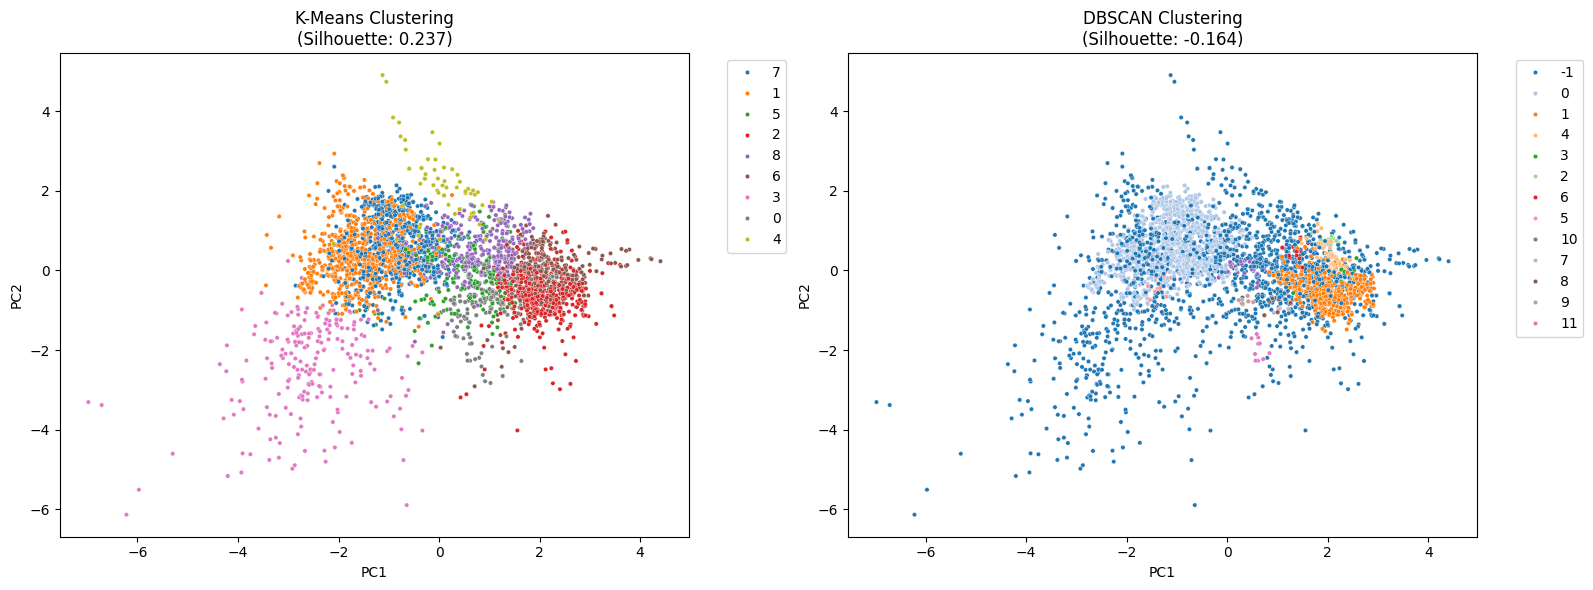

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Load Data
data = pd.read_csv('facies_data2.csv')

features = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE', 'NM_M', 'RELPOS']
X = data[features].dropna() # Hapus baris kosong jika ada

# 2. Preprocessing (Standardization)
# Sangat penting untuk DBSCAN dan K-Means agar skala data sama
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# MODEL 1: K-MEANS (Sebagai Pembanding)
# ==========================================
# Kita gunakan n_clusters=9 (asumsi jumlah facies ada 9 berdasarkan data umum facies)
kmeans = KMeans(n_clusters=9, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# ==========================================
# MODEL 2: DBSCAN (Model Baru)
# ==========================================
# eps: radius lingkungan (perlu dituning, coba 0.5 - 1.0 untuk data terstandarisasi)
# min_samples: minimal titik untuk dianggap cluster
dbscan = DBSCAN(eps=0.6, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

# ==========================================
# 3. EVALUATION METRICS
# ==========================================

def evaluate_model(name, X, labels):
    # Filter out noise (-1) for DBSCAN evaluation purely on clusters (optional but fair)
    # Jika semua dianggap noise, return error
    if len(set(labels)) < 2:
        return None

    sil_score = silhouette_score(X, labels)
    db_score = davies_bouldin_score(X, labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"--- {name} Evaluation ---")
    print(f"Number of Clusters: {n_clusters}")
    print(f"Noise Points (Outliers): {n_noise}")
    print(f"Silhouette Score (Higher is better): {sil_score:.4f}")
    print(f"Davies-Bouldin Index (Lower is better): {db_score:.4f}")
    print("-" * 30)
    return sil_score, db_score

print("Mulai Evaluasi...\n")
k_metrics = evaluate_model("K-Means", X_scaled, kmeans_labels)
d_metrics = evaluate_model("DBSCAN", X_scaled, dbscan_labels)


# Reduksi dimensi ke 2D supaya bisa digambar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Membuat DataFrame untuk plotting
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plot_df['KMeans_Labels'] = kmeans_labels.astype(str)
plot_df['DBSCAN_Labels'] = dbscan_labels.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='KMeans_Labels', palette='tab10', ax=axes[0], s=10)
axes[0].set_title(f'K-Means Clustering\n(Silhouette: {k_metrics[0]:.3f})')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc=2)

# Plot DBSCAN
# Warna -1 biasanya abu-abu atau hitam untuk noise
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='DBSCAN_Labels', palette='tab20', ax=axes[1], s=10)
axes[1].set_title(f'DBSCAN Clustering\n(Silhouette: {d_metrics[0]:.3f})')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc=2)

plt.tight_layout()
plt.show()

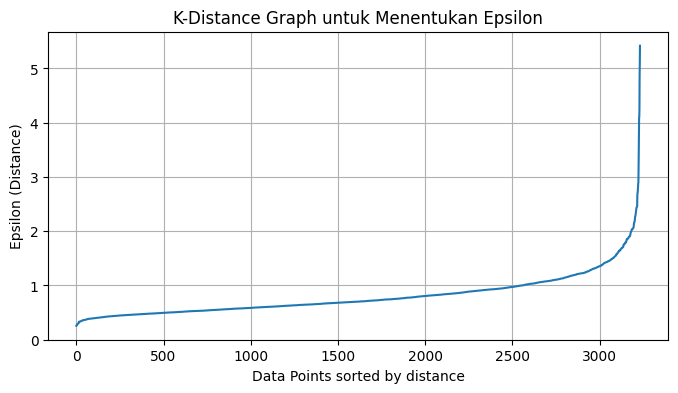

In [ ]:
# Mencari nilai Epsilon (eps) terbaik menggunakan Nearest Neighbors
from sklearn.neighbors import NearestNeighbors

# Hitung jarak ke tetangga terdekat ke-10 (sesuai min_samples=10)
neigh = NearestNeighbors(n_neighbors=10)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Urutkan dan plot jaraknya
distances = np.sort(distances[:,9], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-Distance Graph untuk Menentukan Epsilon')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (Distance)')
plt.grid(True)
plt.show()

"Berdasarkan visualisasi PCA 2D:

Sensitivitas Outlier: Visualisasi menunjukkan DBSCAN lebih unggul dalam mengisolasi data pencilan (noise). Terlihat pada plot kanan dimana titik-titik ekstrim (kemungkinan washout lubang bor atau error alat) tidak dimasukkan ke dalam cluster litologi utama. Sebaliknya, K-Means (kiri) menggabungkan outlier tersebut ke cluster terdekat, yang berpotensi bias pada rata-rata properti fisik batuan.

Geometri Facies: K-Means membentuk partisi berbentuk convex (cenderung membulat), sedangkan DBSCAN mengikuti densitas natural data. Mengingat data petrofisika sering memiliki tren non-linear (seperti 'V-shape' pada log Shale baseline), DBSCAN memberikan representasi yang lebih jujur terhadap kontinuitas data, meskipun sulit untuk mendapatkan jumlah cluster yang spesifik (9 facies) tanpa tuning parameter yang ketat."